In [ ]:
# Cell 1: Imports
import re
from pathlib import Path
import matplotlib.pyplot as plt
from safetensors.torch import load_file
import torch

mkdir -p failed for path /afs/csail.mit.edu/u/a/adrianoh/.config/matplotlib: [Errno 13] Permission denied: '/afs/csail.mit.edu/u/a/adrianoh/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-l_u6pv4k because there was an issue with the default path (/afs/csail.mit.edu/u/a/adrianoh/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [ ]:
# Cell 2: Load and organize data
#
# For this tree
# cache
# ├── ignore_padding_<True|False>
# │   ├── <dataset name>
# │   │   ├── <layer name, no slashes>
# │   │   │   └── distribution.safetensors
# ... (for all padding, dataset, layer in cartesian product)
cache_folder = Path(".cache")

distributions: list[dict[str, torch.Tensor]] = []
files = list(cache_folder.glob("**/*/distribution.safetensors"))
for file in files:
    ignore_padding_folder, dataset_folder, layer_folder = [
        file.parent.parent.parent,
        file.parent.parent,
        file.parent,
    ]
    # print(ignore_padding_folder)
    # print(dataset_folder)
    # print(layer_folder)
    assert ignore_padding_folder.name in [
        "ignore_padding_True",
        "ignore_padding_False",
    ], f"Invalid ignore_padding_folder: {ignore_padding_folder.name}"
    ignore_padding = ignore_padding_folder.name.replace("ignore_padding_", "")
    ignore_padding = ignore_padding == "True"
    dataset = dataset_folder.name
    sae = layer_folder.name.replace("--", "/")
    layer_num = int(re.search(r"layer_(\d+)", layer_folder.name).group(1))

    distribution = load_file(file)["distribution"]
    distributions.append(
        {
            "layer": layer_num,
            "ignore_padding": ignore_padding,
            "dataset": dataset,
            "sae": sae,
            "distribution": distribution,
        }
    )

# Get unique values for organization
layers = sorted(set(d["layer"] for d in distributions))
datasets = sorted(set(d["dataset"] for d in distributions))
print(f"Loaded {len(distributions)} distributions")
print(f"Layers: {layers}")
print(f"Datasets: {datasets}")

Loaded 18 distributions
Layers: [9, 20, 31]
Datasets: ['apps', 'biology', 'ultrachat']


In [ ]:
# Cell 3: Define plotting function with new grid layout
# Layout: 3 columns (datasets) x (2 * n_layers) rows
# For each layer: row 0 = ignore_padding=False, row 1 = ignore_padding=True


def plot_distributions_grid(
    distributions: list[dict],
    sort_by_likelihood: bool = False,
    save_path: str | None = None,
) -> None:
    """
    Plot firing rate distributions in a grid: datasets as columns, layers×padding as rows.

    Grid layout:
        - Columns: one per dataset (alphabetically sorted)
        - Rows: For each layer (sorted), 2 rows:
            - First row: ignore_padding=False
            - Second row: ignore_padding=True

    Args:
        distributions: List of dicts with 'layer', 'ignore_padding', 'dataset', 'distribution'
        sort_by_likelihood: If True, sort neurons by firing rate (descending) for monotonic curves.
        save_path: Optional path to save the figure.
    """
    # Get unique layers and datasets (sorted)
    layers = sorted(set(d["layer"] for d in distributions))
    datasets = sorted(set(d["dataset"] for d in distributions))

    n_layers = len(layers)
    n_datasets = len(datasets)
    n_rows = 2 * n_layers  # 2 rows per layer (False, True)

    fig, axes = plt.subplots(n_rows, n_datasets, figsize=(5 * n_datasets, 3 * n_rows))

    # Ensure axes is always 2D
    if n_rows == 1 and n_datasets == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_datasets == 1:
        axes = [[ax] for ax in axes]

    sort_label = "Sorted by Firing Rate" if sort_by_likelihood else "By Neuron Index"
    x_label = "Neuron Rank" if sort_by_likelihood else "Neuron Index"

    # Colors for ignore_padding values
    colors = {False: "steelblue", True: "coral"}

    # Create lookup dict for quick access: (layer, ignore_padding, dataset) -> distribution
    dist_lookup: dict[tuple[int, bool, str], torch.Tensor] = {}
    for d in distributions:
        key = (d["layer"], d["ignore_padding"], d["dataset"])
        dist_lookup[key] = d["distribution"]

    for layer_idx, layer in enumerate(layers):
        for padding_idx, ignore_padding in enumerate([False, True]):
            row_idx = layer_idx * 2 + padding_idx
            padding_str = "True" if ignore_padding else "False"

            for col_idx, dataset in enumerate(datasets):
                ax = axes[row_idx][col_idx]
                key = (layer, ignore_padding, dataset)

                if key not in dist_lookup:
                    ax.text(
                        0.5,
                        0.5,
                        "No data",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                    )
                    ax.set_title(
                        f"L{layer} | pad={padding_str} | {dataset}", fontsize=10
                    )
                    continue

                dist = dist_lookup[key]
                if sort_by_likelihood:
                    dist, _ = torch.sort(dist, descending=True)
                dist_np = dist.numpy()

                ax.plot(dist_np, color=colors[ignore_padding], linewidth=0.8)
                ax.set_title(f"L{layer} | pad={padding_str} | {dataset}", fontsize=10)
                ax.set_xlabel(x_label)
                ax.set_ylabel("Firing Fraction")
                ax.set_yscale("log")

    plt.suptitle(f"SAE Neuron Firing Distributions ({sort_label})", fontsize=14, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

=== Sorted by firing rate (descending) ===


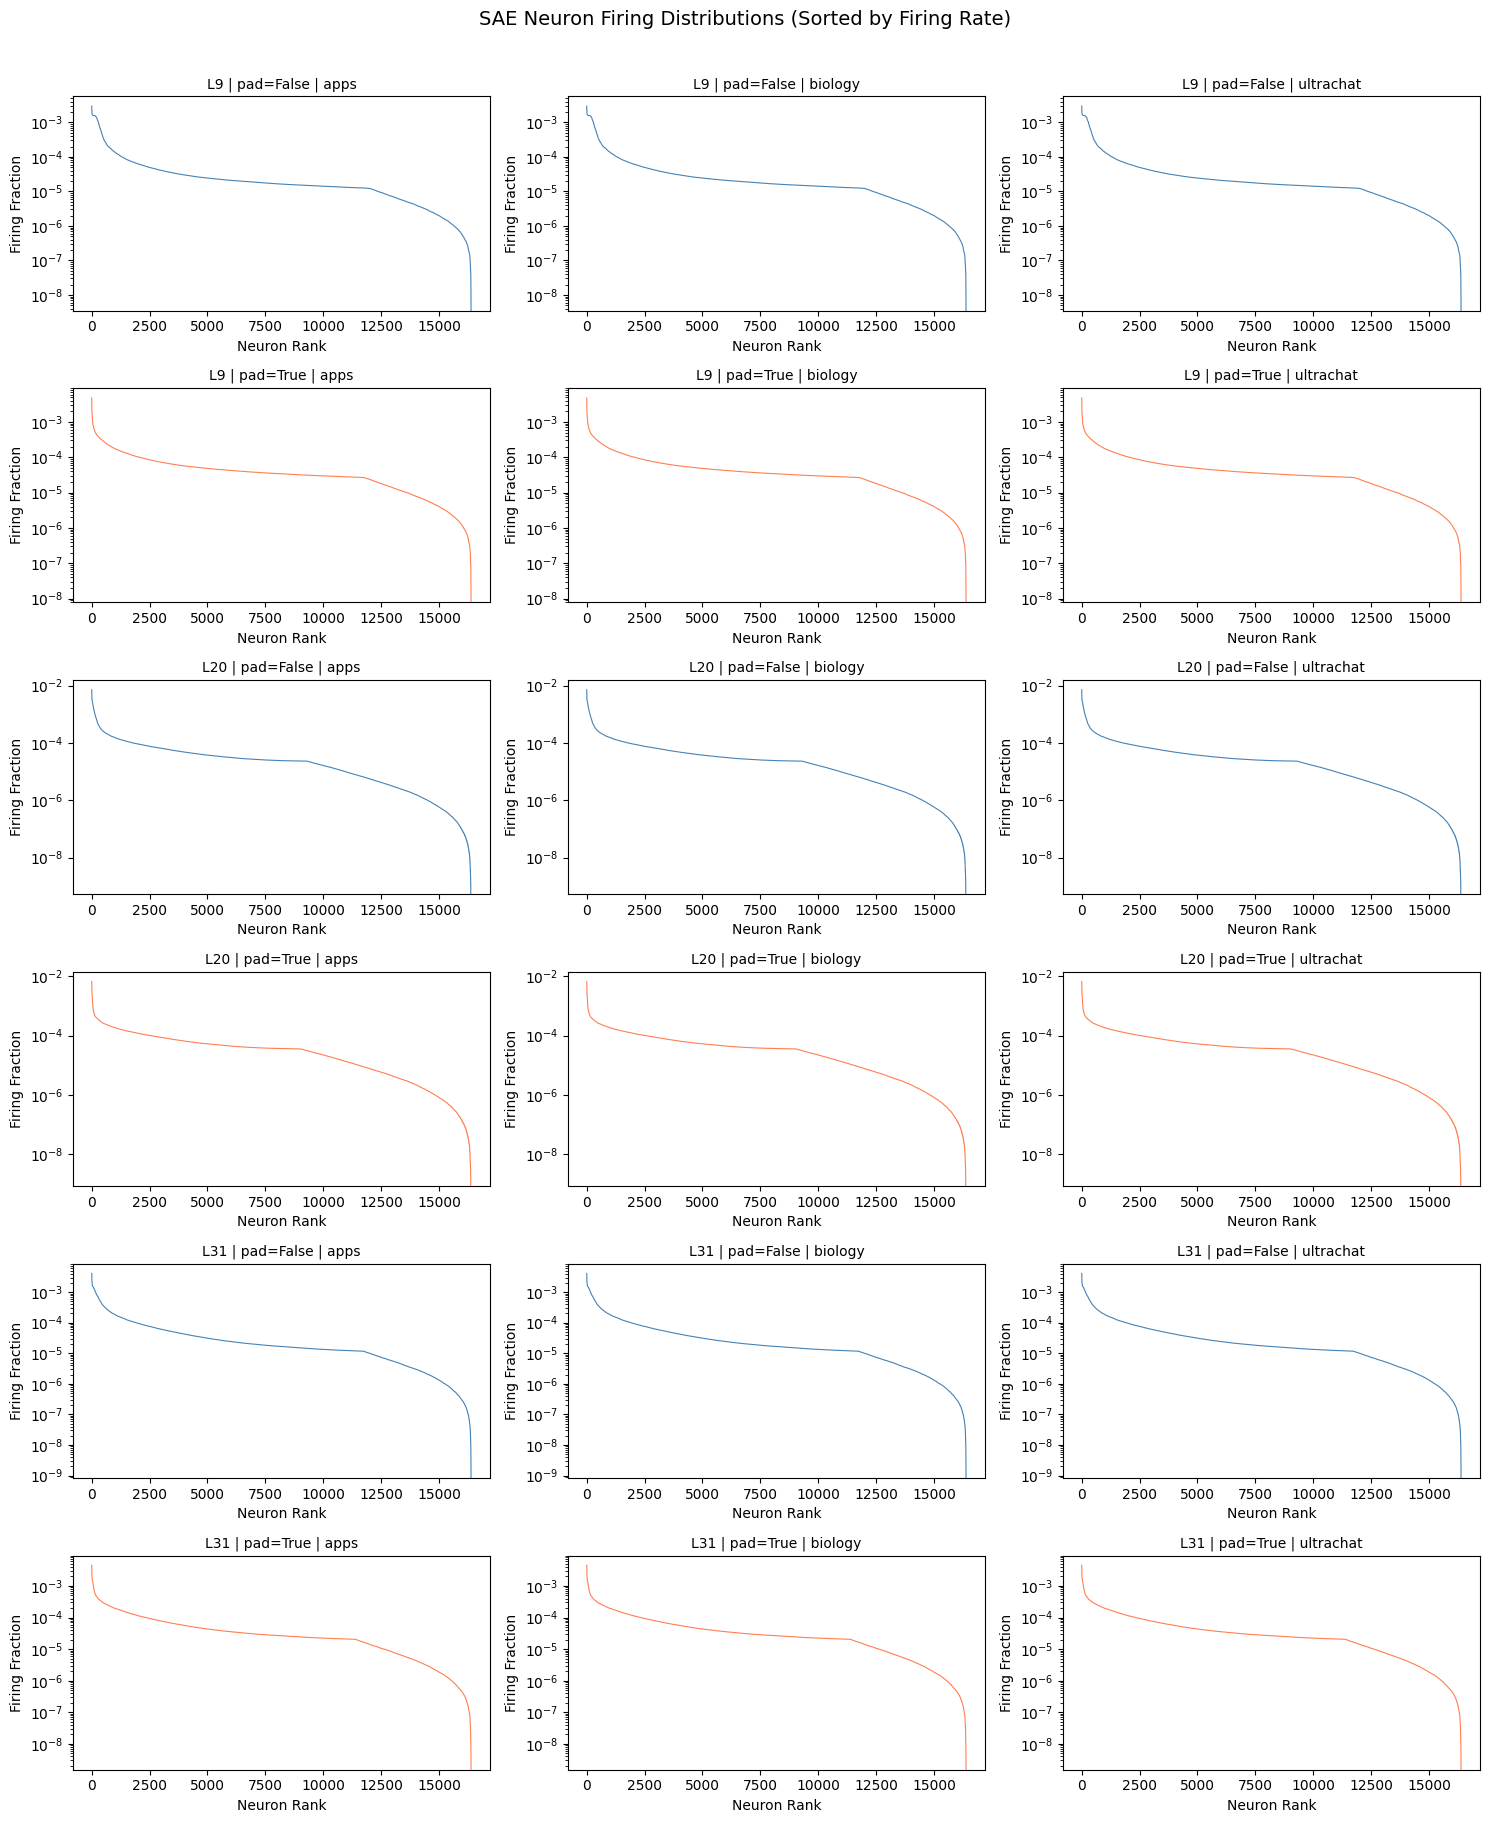

In [ ]:
# Cell 4: Plot with sorted firing rates (nice monotonic curves)
print("=== Sorted by firing rate (descending) ===")
plot_distributions_grid(
    distributions,
    sort_by_likelihood=True,
    save_path="distributions_sorted.png",
)

=== By neuron index (unsorted) ===


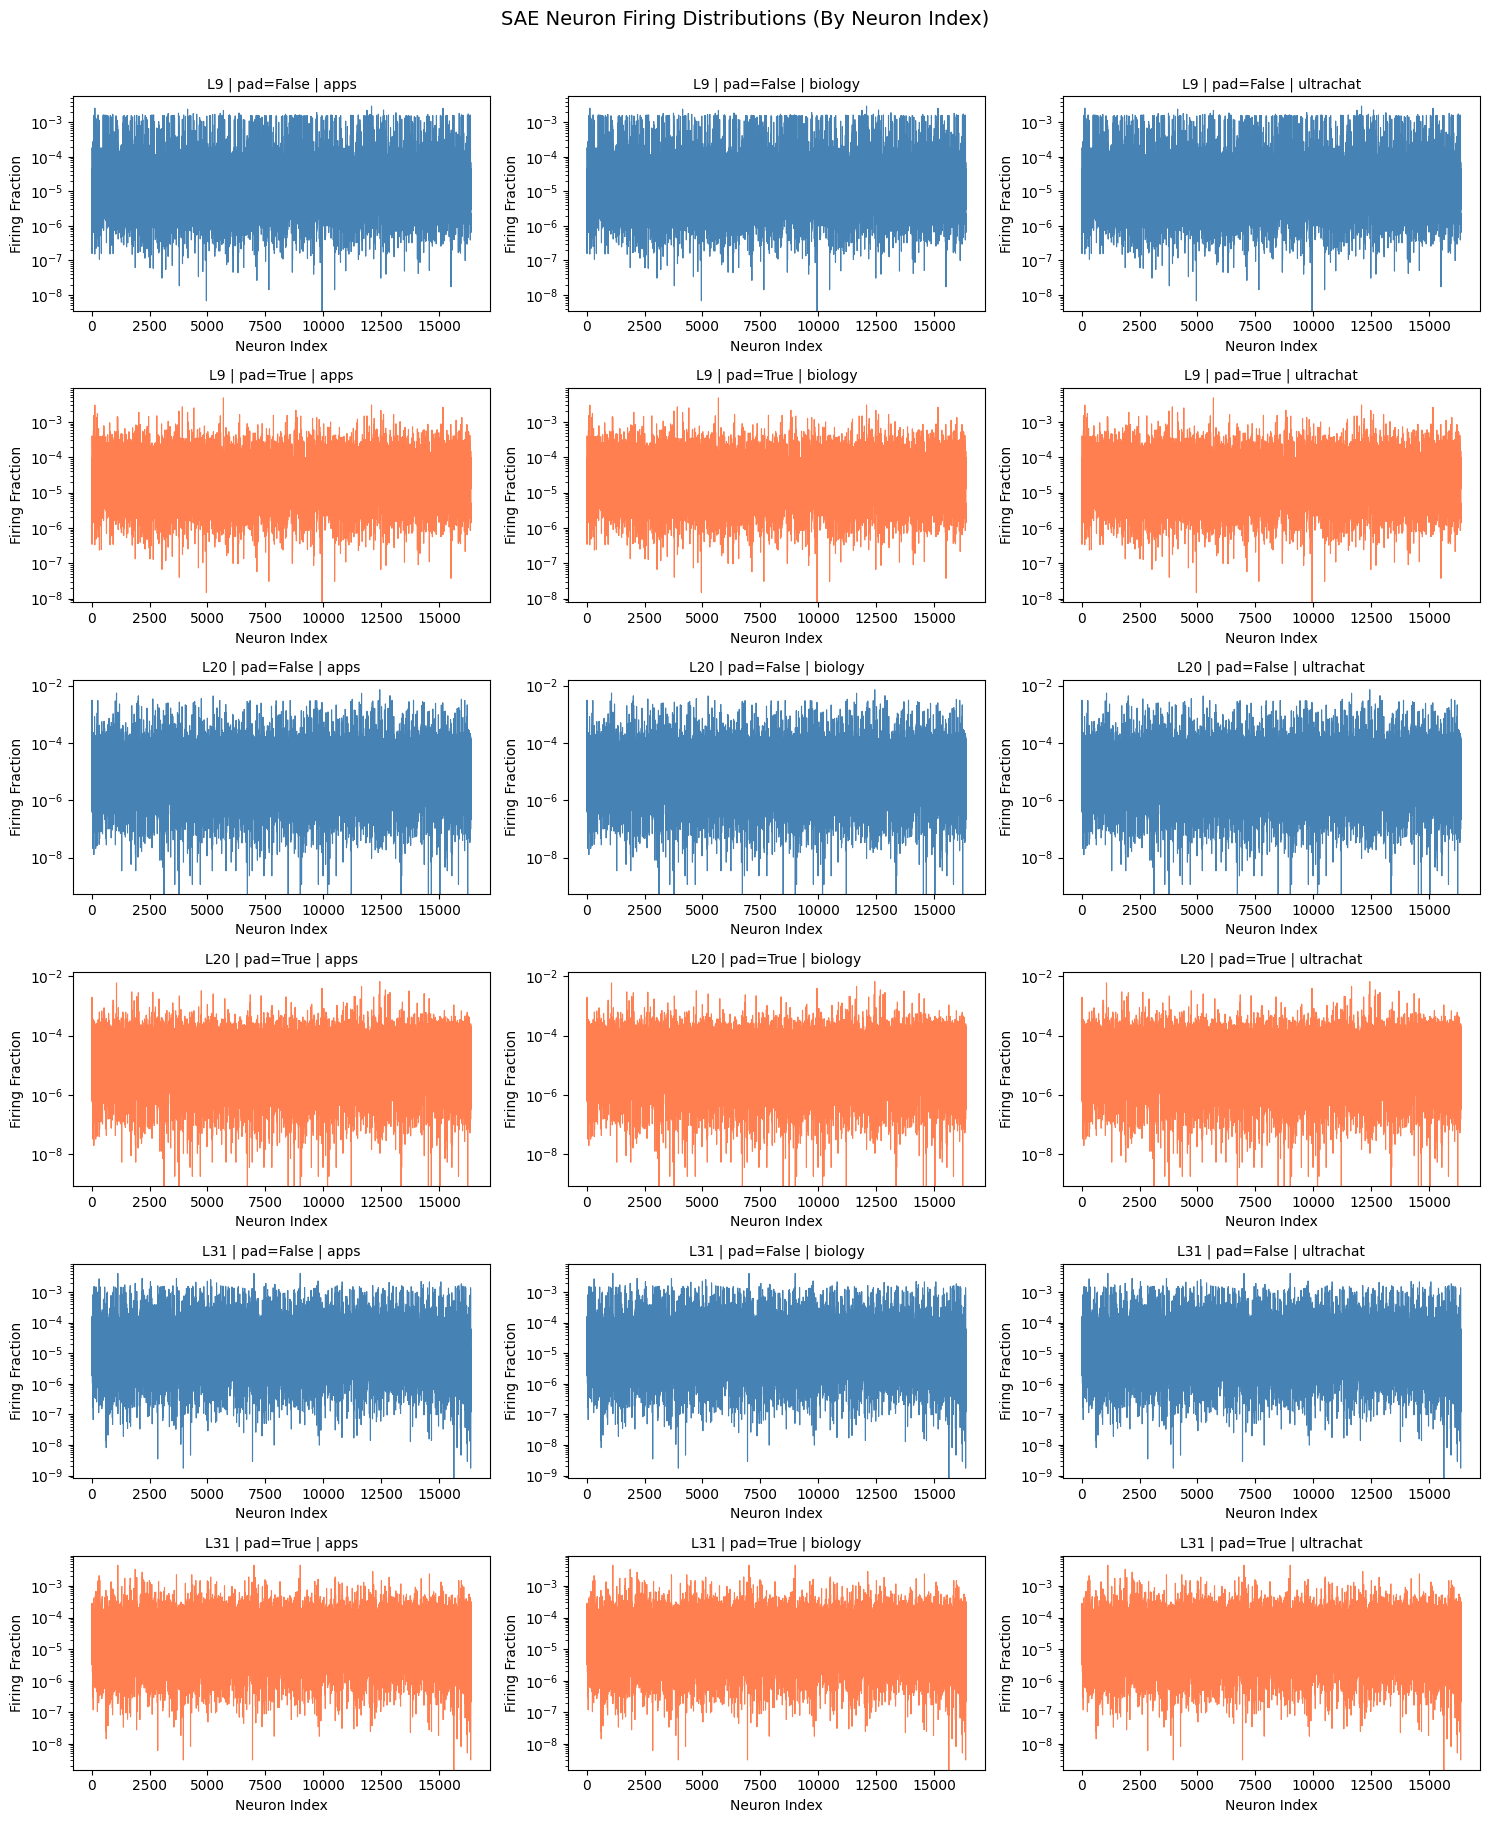

In [ ]:
# Cell 5: Plot by neuron index (honest to original ordering)
print("=== By neuron index (unsorted) ===")
plot_distributions_grid(
    distributions,
    sort_by_likelihood=False,
    save_path="distributions_by_index.png",
)

In [ ]:
# Cell: Generic pairwise comparison function
from typing import Callable


def compute_pairwise_matrix(
    vectors: list[torch.Tensor],
    metric_fn: Callable[[torch.Tensor, torch.Tensor], float | torch.Tensor],
    assume_symmetric: bool = False,
    identity_is: float | None = None,
) -> torch.Tensor:
    """
    Compute a pairwise comparison matrix for all pairs of vectors using a given metric.

    Args:
        vectors: List of 1D tensors to compare pairwise.
        metric_fn: Callable that takes two tensors and returns a scalar (or 0D tensor).
        assume_symmetric: If True, only compute upper triangle and mirror to lower.
                         Useful for symmetric metrics like MSE, MAE, cosine similarity.
        identity_is: If None, compute metric_fn(v, v) for diagonal entries.
                    If a value, set all diagonal entries to that value (e.g., 0.0 for distances).

    Returns:
        A [n, n] tensor where entry [i, j] = metric_fn(vectors[i], vectors[j])
    """
    n = len(vectors)
    result = torch.zeros(n, n, dtype=torch.float32)

    for i in range(n):
        for j in range(n):
            # Handle diagonal
            if i == j:
                if identity_is is not None:
                    result[i, j] = identity_is
                else:
                    result[i, j] = metric_fn(vectors[i], vectors[j])
                continue

            # If symmetric and we already computed [j, i], mirror it
            if assume_symmetric and j < i:
                result[i, j] = result[j, i]
            else:
                result[i, j] = metric_fn(vectors[i], vectors[j])

    return result


# Common metric functions
def mae(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Mean Absolute Error"""
    return (a - b).abs().mean()


def mse(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Mean Squared Error"""
    return ((a - b) ** 2).mean()


def cosine_similarity(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """Cosine similarity (1 = identical direction, 0 = orthogonal, -1 = opposite)"""
    return torch.nn.functional.cosine_similarity(
        a.unsqueeze(0), b.unsqueeze(0)
    ).squeeze()


def kl_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-10) -> torch.Tensor:
    """KL divergence D_KL(P || Q) - note: NOT symmetric"""
    p_safe = p.clamp(min=eps)
    q_safe = q.clamp(min=eps)
    return (p_safe * (p_safe / q_safe).log()).sum()


def js_divergence(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-10) -> torch.Tensor:
    """Jensen-Shannon divergence - symmetric version of KL"""
    m = 0.5 * (p + q)
    return 0.5 * kl_divergence(p, m, eps) + 0.5 * kl_divergence(q, m, eps)

In [ ]:
# Cell: Build pairwise MAE per layer (comparing all datasets × padding combinations)
# Each layer gets its own comparison matrix, no cross-layer comparisons

# Create lookup for quick access
dist_lookup: dict[tuple[int, bool, str], torch.Tensor] = {}
for d in distributions:
    key = (d["layer"], d["ignore_padding"], d["dataset"])
    dist_lookup[key] = d["distribution"]

# Get unique values
layers = sorted(set(d["layer"] for d in distributions))
datasets = sorted(set(d["dataset"] for d in distributions))

print(f"Layers: {layers}")
print(f"Datasets: {datasets}")

# Compute pairwise MAE for each layer
pairwise_mae_per_layer: dict[int, tuple[torch.Tensor, list[str]]] = {}

for layer in layers:
    ordered_vectors: list[torch.Tensor] = []
    labels: list[str] = []

    # Order: all datasets × (nopad, pad)
    for dataset in datasets:
        for ignore_padding in [False, True]:
            key = (layer, ignore_padding, dataset)
            pad_str = "pad" if ignore_padding else "nopad"
            if key in dist_lookup:
                ordered_vectors.append(dist_lookup[key])
                labels.append(f"{dataset}_{pad_str}")

    # Compute pairwise MAE for this layer
    pairwise_mae = compute_pairwise_matrix(
        vectors=ordered_vectors,
        metric_fn=mae,
        assume_symmetric=True,
        identity_is=0.0,
    )

    pairwise_mae_per_layer[layer] = (pairwise_mae, labels)
    print(f"\nLayer {layer}: {len(labels)} vectors, shape {pairwise_mae.shape}")
    print(f"  Pairwise MAE: {pairwise_mae}")
    print(f"  Labels: {labels}")

Layers: [9, 20, 31]
Datasets: ['apps', 'biology', 'ultrachat']

Layer 9: 6 vectors, shape torch.Size([6, 6])
  Pairwise MAE: tensor([[0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05],
        [5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00],
        [0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05],
        [5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00],
        [0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05],
        [5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00, 5.9729e-05, 0.0000e+00]])
  Labels: ['apps_nopad', 'apps_pad', 'biology_nopad', 'biology_pad', 'ultrachat_nopad', 'ultrachat_pad']

Layer 20: 6 vectors, shape torch.Size([6, 6])
  Pairwise MAE: tensor([[0.0000e+00, 3.6791e-05, 0.0000e+00, 3.6791e-05, 0.0000e+00, 3.6791e-05],
        [3.6791e-05, 0.0000e+00, 3.6791e-05, 0.0000e+00, 3.6791e-05, 0.0000e+00],
        [0.0000e+00, 3.6791e-05, 0.0000e+00, 3.679

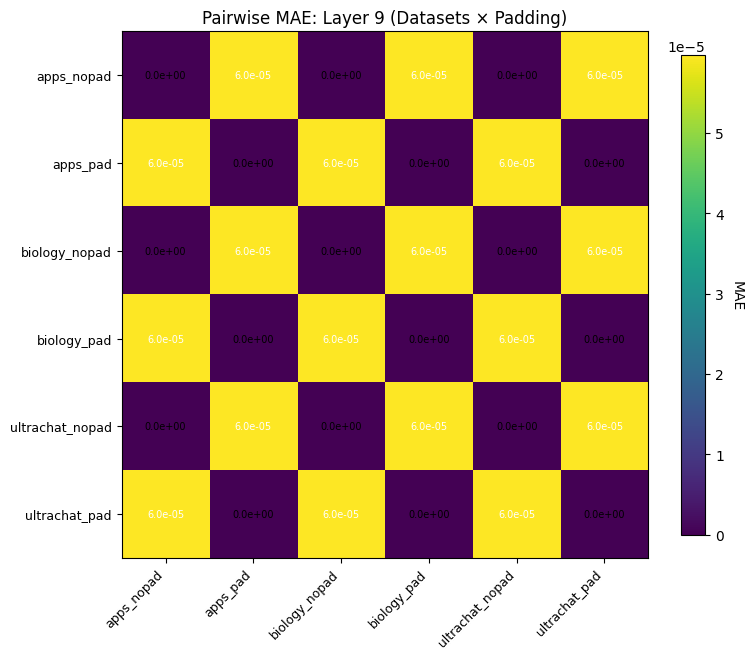

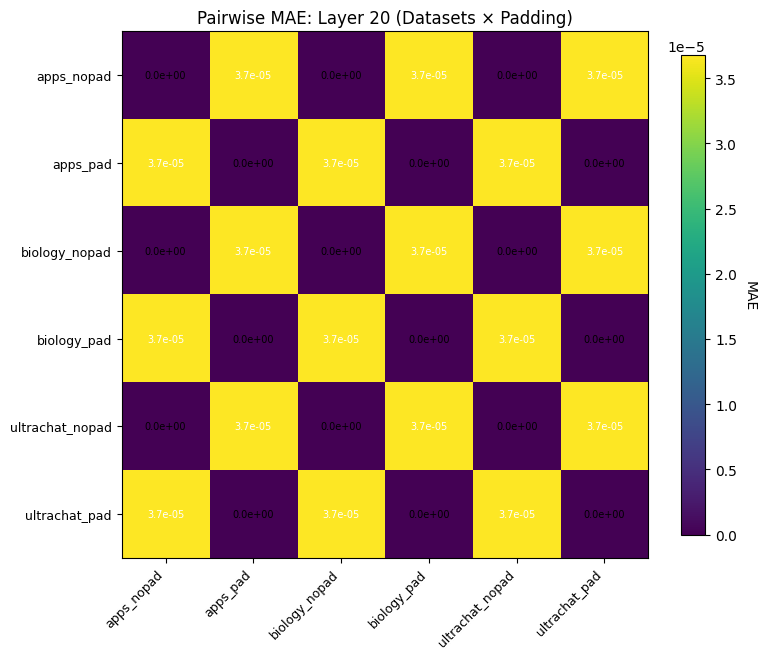

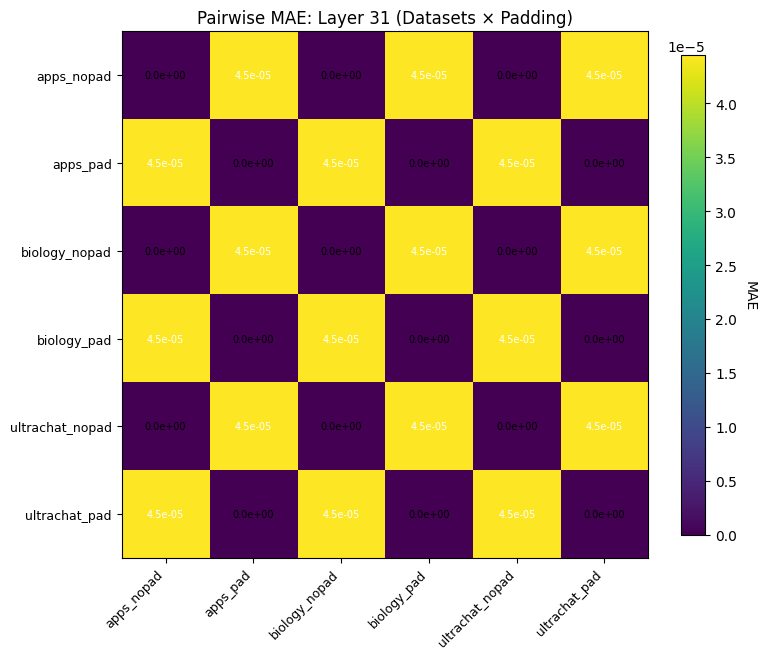

In [ ]:
# Cell: Visualize pairwise MAE heatmaps (one per layer)
import numpy as np


def plot_pairwise_mae_heatmap(
    pairwise_mae: torch.Tensor,
    labels: list[str],
    title: str,
    save_path: str | None = None,
) -> None:
    """
    Plot a single pairwise MAE heatmap.

    Args:
        pairwise_mae: Square tensor of pairwise MAE values.
        labels: List of labels for rows/columns.
        title: Title for the plot.
        save_path: Optional path to save the figure.
    """
    fig, ax = plt.subplots(figsize=(8, 7))

    im = ax.imshow(pairwise_mae.numpy(), cmap="viridis")

    # Add labels
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.ax.set_ylabel("MAE", rotation=-90, va="bottom")

    # Add text annotations in each cell
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = pairwise_mae[i, j].item()
            text_color = "white" if val > pairwise_mae.max().item() / 2 else "black"
            ax.text(
                j,
                i,
                f"{val:.1e}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=7,
            )

    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


# Plot each layer separately
for layer in sorted(pairwise_mae_per_layer.keys()):
    pairwise_mae, labels = pairwise_mae_per_layer[layer]
    plot_pairwise_mae_heatmap(
        pairwise_mae,
        labels,
        title=f"Pairwise MAE: Layer {layer} (Datasets × Padding)",
        save_path=f"pairwise_mae_layer_{layer}.png",
    )

In [ ]:
# Debug cell: Verify data uniqueness
# Check if distributions are actually different or if we're loading duplicates

print("=== Checking data uniqueness ===\n")

# Group distributions by layer
for layer in layers:
    print(f"Layer {layer}:")
    layer_dists = [d for d in distributions if d["layer"] == layer]

    # Print tensor IDs to check if they're the same object
    for d in layer_dists:
        tensor = d["distribution"]
        print(
            f"  {d['dataset']}_{'pad' if d['ignore_padding'] else 'nopad'}: "
            f"id={id(tensor)}, sum={tensor.sum().item():.6f}, mean={tensor.mean().item():.2e}"
        )

    # Check pairwise equality
    print(f"\n  Exact equality checks:")
    nopad_dists = [
        (d["dataset"], d["distribution"])
        for d in layer_dists
        if not d["ignore_padding"]
    ]
    for i, (name_i, dist_i) in enumerate(nopad_dists):
        for name_j, dist_j in nopad_dists[i + 1 :]:
            is_equal = torch.equal(dist_i, dist_j)
            print(f"    {name_i}_nopad == {name_j}_nopad: {is_equal}")
    print()

=== Checking data uniqueness ===

Layer 9:
  biology_nopad: id=140091122455472, sum=1.000000, mean=6.10e-05
  ultrachat_nopad: id=140091122459792, sum=1.000000, mean=6.10e-05
  apps_nopad: id=140091122430544, sum=1.000000, mean=6.10e-05
  ultrachat_pad: id=140091122424464, sum=1.000000, mean=6.10e-05
  biology_pad: id=140091122424224, sum=1.000000, mean=6.10e-05
  apps_pad: id=140091122324480, sum=1.000000, mean=6.10e-05

  Exact equality checks:
    biology_nopad == ultrachat_nopad: True
    biology_nopad == apps_nopad: True
    ultrachat_nopad == apps_nopad: True

Layer 20:
  biology_nopad: id=140091122459312, sum=1.000000, mean=6.10e-05
  ultrachat_nopad: id=140091122460432, sum=1.000000, mean=6.10e-05
  apps_nopad: id=140091122425984, sum=1.000000, mean=6.10e-05
  ultrachat_pad: id=140091122425744, sum=1.000000, mean=6.10e-05
  biology_pad: id=140091122424704, sum=1.000000, mean=6.10e-05
  apps_pad: id=140091122324000, sum=1.000000, mean=6.10e-05

  Exact equality checks:
    biolo